# Geographical analysis of topics

## Create data file

In [38]:
import pandas as pd
import numpy as np
import requests
from tqdm import tqdm
import time
from data_load import load_data_for_modeling
import folium
from folium.plugins import HeatMap
import plotly.express as px
import plotly.io as pio
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np


In [46]:
geodata = pd.read_excel(
    "geodata.xlsx",
    header=2
)

In [47]:
data = load_data_for_modeling(
    data_folder="data",
    label_columns=[
        "encoded_accident_situation",
        "report_category",
        "main_situation_class"
    ],
    combine_labels=False,
    verbose=True,
)

Loading all Excel files...
Loading: data.xlsx
Combined dataset shape: (50, 7)
After cleaning: (50, 9)

Total documents for modeling: 50
Unique labels (encoded_accident_situation): [21, 22, 24, 32, 50, 140, 151, 170, 198, 211, 241, 250, 312, 398, 410, 420, 440, 520, 640, 642, 644, 650, 670, 710, 720, 740, 751, 752, 811, 831, 851, 860, 874, 876, 877, 879, 880, 910, 920, 940, 999]
Unique labels (report_category): ['Anmsuh', 'Exuh', 'Mskpuh', 'Pskduh']
Unique labels (main_situation_class): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [48]:
data = data["df"]

In [49]:
missing_xy = geodata[geodata["X_KOORDINAT"].isna() | geodata["Y_KOORDINAT"].isna()]

print("Crashes with missing x or y:", len(missing_xy))
print("Share of all crashes:", round(len(missing_xy) / len(geodata) * 100, 2), "%")

Crashes with missing x or y: 17
Share of all crashes: 34.0 %


In [50]:
df_geo = data.merge(
    geodata,
    on="UHELDS_ID",
    how="left"
)

In [51]:
def parse_geometry(value):

    if pd.isna(value):
        return (np.nan, np.nan)

    try:
        value = str(value)

        # remove M
        value = value.replace("M", "")

        # remove trailing comma
        value = value.rstrip(",")

        # split
        x_raw, y_raw = value.split(",")

        # convert
        x = float(x_raw) / 10000
        y = -float(y_raw) / 10000

        return (x, y)

    except:
        return (np.nan, np.nan)


coords = df_geo["UH_GEOMETRI"].apply(parse_geometry)

df_geo["x"] = coords.apply(lambda c: c[0])
df_geo["y"] = coords.apply(lambda c: c[1])

print(df_geo.head())

   UHELDS_ID accident_date report_category  encoded_accident_situation  \
0          1    01-01-2025          Mskpuh                         398   
1          2    08-01-2025          Anmsuh                         170   
2          3    15-01-2025          Pskduh                         250   
3          4    22-01-2025          Anmsuh                         910   
4          5    29-01-2025          Mskpuh                         751   

   accident_situation     police_narrative  year  main_situation_class  \
0                 398  This is narrative 1  2025                     3   
1                 170  This is narrative 2  2025                     1   
2                 250  This is narrative 3  2025                     2   
3                 910  This is narrative 4  2025                     9   
4                 751  This is narrative 5  2025                     7   

   n_words UH_GEOMETRI  ADM_VEJ1_NR  KODE_UHELDKOMMUNE  X_KOORDINAT  \
0        4         NaN     483721.0    

In [52]:
print(df_geo["UH_GEOMETRI"].isna().sum())

18


In [53]:
# clean road codes
def extract_vejkode(value):

    if pd.isna(value):
        return np.nan

    value = str(value)

    value = value.replace(".0", "")
    value = value.strip()

    length = len(value)

    # length 1-4
    if length <= 4:
        return value

    # length 5 -> discard
    elif length == 5:
        return np.nan

    # length 6 -> remove first 2 digits
    elif length == 6:
        return value[2:]

    # length 7 -> remove first 3 digits
    elif length == 7:
        return value[3:]

    else:
        return np.nan


df_geo["vejkode_clean"] = (
    df_geo["ADM_VEJ1_NR"]
    .apply(extract_vejkode)
)

df_geo["vejkode_clean"] = pd.to_numeric(
    df_geo["vejkode_clean"],
    errors="coerce"
).astype("Int64")

In [54]:
# rows missing coordinates
missing_mask = (
    df_geo["x"].isna()
    & df_geo["y"].isna()
)

missing_df = df_geo.loc[
    missing_mask,
    ["KODE_UHELDKOMMUNE", "vejkode_clean"]
].copy()

# keep rows with kommune + vejkode
missing_df = missing_df.dropna(
    subset=["KODE_UHELDKOMMUNE", "vejkode_clean"]
)

# unique pairs
unique_pairs = (
    missing_df[
        ["KODE_UHELDKOMMUNE", "vejkode_clean"]
    ]
    .drop_duplicates()
    .reset_index(drop=True)
)

print(len(unique_pairs))

15


In [55]:
pair_counts = (
    missing_df
    .groupby(["KODE_UHELDKOMMUNE", "vejkode_clean"])
    .size()
    .reset_index(name="n_crashes")
    .sort_values("n_crashes", ascending=False)
)

print(pair_counts.head(20))
print("Number of unique pairs:", len(pair_counts))
print("Total crashes with missing coordinates but kommune + vejkode:", pair_counts["n_crashes"].sum())

    KODE_UHELDKOMMUNE  vejkode_clean  n_crashes
0               101.0           3721          1
1               147.0           2945          1
2               151.0           1204          1
3               153.0           4812          1
4               155.0           6153          1
5               157.0           7291          1
6               159.0           3920          1
7               161.0           2487          1
8               163.0           5638          1
9               165.0           8194          1
10              175.0           5204          1
11              183.0           7890          1
12              185.0           8126          1
13              187.0           2945          1
14              190.0           1582          1
Number of unique pairs: 15
Total crashes with missing coordinates but kommune + vejkode: 15


In [56]:
# API lookup
def get_coordinates(kommune, vejkode):

    try:

        kommune = int(kommune)
        vejkode = int(vejkode)

        url = (
            f"https://api.dataforsyningen.dk/"
            f"vejstykker/{kommune}/{vejkode}"
        )

        response = requests.get(url, timeout=10)

        if response.status_code != 200:
            return (np.nan, np.nan)

        data = response.json()

        if isinstance(data, dict):

            coords = data.get("visueltcenter")

            if coords is not None:
                return (coords[0], coords[1])

        return (np.nan, np.nan)

    except:
        return (np.nan, np.nan)

In [57]:
x_list = []
y_list = []

for _, row in tqdm(
    unique_pairs.iterrows(),
    total=len(unique_pairs)
):

    x, y = get_coordinates(
        row["KODE_UHELDKOMMUNE"],
        row["vejkode_clean"]
    )

    x_list.append(x)
    y_list.append(y)

    time.sleep(0.02)


unique_pairs["x_api"] = x_list
unique_pairs["y_api"] = y_list

100%|██████████| 15/15 [00:17<00:00,  1.15s/it]


In [58]:
df_geo2 = df_geo.merge(
    unique_pairs,
    on=["KODE_UHELDKOMMUNE", "vejkode_clean"],
    how="left"
)

# fill missing
df_geo2["x"] = df_geo2["x"].fillna(
    df_geo2["x_api"]
)

df_geo2["y"] = df_geo2["y"].fillna(
    df_geo2["y_api"]
)

# cleanup
df_geo2 = df_geo2.drop(
    columns=["x_api", "y_api"]
)

print(df_geo2["x"].isna().sum())
print(df_geo2["y"].isna().sum())

17
17


In [65]:
# save file
df_geo2.to_csv("df_final.csv", index=False)

print("File saved successfully.")

File saved successfully.


## Load data file

In [67]:
# Load parquet file
df_final = pd.read_csv(
    "df_final.csv"
)

# Check
print(df_final.shape)
df_final.head()

(50, 17)


,UHELDS_ID,accident_date,report_category,encoded_accident_situation,accident_situation,police_narrative,year,main_situation_class,n_words,UH_GEOMETRI,ADM_VEJ1_NR,KODE_UHELDKOMMUNE,X_KOORDINAT,Y_KOORDINAT,x,y,vejkode_clean
0,1,01-01-2025,Mskpuh,398,398,This is narrative 1,2025,3,4,NaN,483721.0,101.0,NaN,NaN,12.600747,55.706911,3721.0
1,2,08-01-2025,Anmsuh,170,170,This is narrative 2,2025,1,4,NaN,612945.0,147.0,NaN,NaN,NaN,NaN,2945.0
2,3,15-01-2025,Pskduh,250,250,This is narrative 3,2025,2,4,NaN,751204.0,151.0,NaN,NaN,NaN,NaN,1204.0
3,4,22-01-2025,Anmsuh,910,910,This is narrative 4,2025,9,4,NaN,394812.0,153.0,NaN,NaN,NaN,NaN,4812.0
4,5,29-01-2025,Mskpuh,751,751,This is narrative 5,2025,7,4,NaN,826153.0,155.0,NaN,NaN,NaN,NaN,6153.0


In [71]:
# merge topics from all configs
main03 = pd.read_csv(
    "document_topics.csv"
)

df_final = df_final.merge(
    main03,
    left_on="UHELDS_ID",
    right_on="document_index",
    how="left"
)

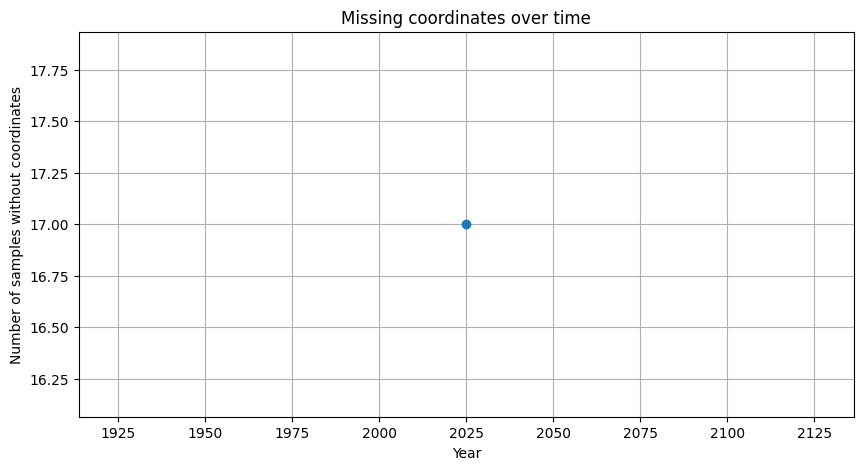

In [78]:
import pandas as pd
import matplotlib.pyplot as plt

# Convert date column to datetime
df_final["accident_date"] = pd.to_datetime(
    df_final["accident_date"],
    format="%d-%m-%Y"
)

# Create indicator for missing coordinates
missing_coords = (
    df_final["x"].isna() | 
    df_final["y"].isna()
)

# Group by year (or month)
missing_over_time = (
    df_final[missing_coords]
    .groupby(df_final["accident_date"].dt.year)
    .size()
)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(missing_over_time.index, missing_over_time.values, marker='o')

plt.xlabel("Year")
plt.ylabel("Number of samples without coordinates")
plt.title("Missing coordinates over time")

plt.grid(True)
plt.show()

In [79]:
missing_both = df_final[
    (
        df_final["x"].isna() |
        df_final["y"].isna()
    )
    &
    (
        df_final["KODE_UHELDKOMMUNE"].isna()
    )
]

print(len(missing_both))

0


In [80]:
import geopandas as gpd

kommuner = gpd.read_file("municipalities.geojson")

In [81]:
# Calculate centroid for each polygon
kommuner["centroid"] = kommuner.geometry.centroid

# Extract coordinates
kommuner["centroid_x"] = kommuner.centroid.x
kommuner["centroid_y"] = kommuner.centroid.y

# Create ONE centroid per kommune
centroids_clean = (
    kommuner
    .groupby("lau_1", as_index=False)[["centroid_x", "centroid_y"]]
    .mean()
)

/var/folders/1m/z6bjwn212yg9839rhl52qvtm0000gn/T/ipykernel_95461/195626513.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  kommuner["centroid"] = kommuner.geometry.centroid
/var/folders/1m/z6bjwn212yg9839rhl52qvtm0000gn/T/ipykernel_95461/195626513.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  kommuner["centroid_x"] = kommuner.centroid.x
/var/folders/1m/z6bjwn212yg9839rhl52qvtm0000gn/T/ipykernel_95461/195626513.py:6: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  kommuner["centroid_y"] = kommuner.centroid.y


In [83]:
# Merge
df_final["KODE_UHELDKOMMUNE"] = (
    df_final["KODE_UHELDKOMMUNE"]
    .astype(int)
    .astype(str)
)

df_final = df_final.merge(
    centroids_clean,
    left_on="KODE_UHELDKOMMUNE",
    right_on="lau_1",
    how="left"
)

In [84]:
df_final["x"] = df_final["x"].fillna(df_final["centroid_x"])
df_final["y"] = df_final["y"].fillna(df_final["centroid_y"])

In [85]:
df_final = df_final.drop(
    columns=["lau_1", "centroid_x", "centroid_y"]
)

In [86]:
df_final = df_final[
    df_final["x"].notna() &
    df_final["y"].notna()
]

In [87]:
save_path = "df_coords.csv"
df_final.to_csv(save_path, index=False)
print("Saved to:", save_path)

Saved to: df_coords.csv


In [88]:
remaining_missing_df = df_final[
    df_final["x"].isna() |
    df_final["y"].isna()
]

print("Remaining missing rows:", len(remaining_missing_df))

Remaining missing rows: 0


In [89]:
# remove missing coordinates
df_test = df_final.copy()
df_test = df_test.dropna(
    subset=["x", "y"]
)

print(df_test.shape)

(50, 20)


In [90]:
# add kommunetype
kommune_groups = {
    # 1 — Hovedstadskommuner
    101: "Hovedstad", 147: "Hovedstad", 151: "Hovedstad",
    153: "Hovedstad", 155: "Hovedstad", 157: "Hovedstad",
    159: "Hovedstad", 161: "Hovedstad", 163: "Hovedstad",
    165: "Hovedstad", 167: "Hovedstad", 169: "Hovedstad",
    173: "Hovedstad", 175: "Hovedstad", 183: "Hovedstad",
    185: "Hovedstad", 187: "Hovedstad", 190: "Hovedstad",
    201: "Hovedstad", 223: "Hovedstad", 230: "Hovedstad",
    240: "Hovedstad", 253: "Hovedstad", 269: "Hovedstad",

    # 2 — Storbykommuner
    461: "Storby", 751: "Storby", 851: "Storby",

    # 3 — Provinsbykommuner
    217: "Provinsby", 219: "Provinsby", 259: "Provinsby",
    265: "Provinsby", 330: "Provinsby", 370: "Provinsby",
    561: "Provinsby", 607: "Provinsby", 615: "Provinsby",
    621: "Provinsby", 630: "Provinsby", 657: "Provinsby",
    661: "Provinsby", 730: "Provinsby", 740: "Provinsby",
    791: "Provinsby",

    # 4 — Oplandskommuner
    210: "Opland", 250: "Opland", 260: "Opland",
    270: "Opland", 316: "Opland", 320: "Opland",
    329: "Opland", 336: "Opland", 340: "Opland",
    350: "Opland", 410: "Opland", 420: "Opland",
    430: "Opland", 440: "Opland", 450: "Opland",
    480: "Opland", 575: "Opland", 706: "Opland",
    710: "Opland", 727: "Opland", 746: "Opland",
    756: "Opland", 766: "Opland", 840: "Opland",

    # 5 — Landkommuner
    306: "Land", 326: "Land", 360: "Land",
    376: "Land", 390: "Land", 400: "Land",
    479: "Land", 482: "Land", 492: "Land",
    510: "Land", 530: "Land", 540: "Land",
    550: "Land", 563: "Land", 573: "Land",
    580: "Land", 665: "Land", 671: "Land",
    707: "Land", 741: "Land", 760: "Land",
    773: "Land", 779: "Land", 787: "Land",
    810: "Land", 813: "Land", 820: "Land",
    825: "Land", 846: "Land", 849: "Land",
    860: "Land",
}

# apply to df_merged
df_test["kommune_group"] = df_test["KODE_UHELDKOMMUNE"].map(kommune_groups)

# check coverage
print(df_test["kommune_group"].value_counts(dropna=False))
print(f"\nUnmapped: {df_test['kommune_group'].isna().sum():,}")

kommune_group
NaN    50
Name: count, dtype: int64

Unmapped: 50


### "Full" dataset

In [91]:
# heat map
m = folium.Map(
    location=[56.0, 10.0],
    zoom_start=7
)

heat_data = df_test[["y", "x"]].values.tolist()

HeatMap(
    heat_data,
    radius=3,
    blur=2
).add_to(m)
m

### Main 0.3

In [96]:
#plot labels on the map
import plotly.express as px

# labels map
fig_labels = px.scatter_mapbox(
    df_test,
    lat="y",
    lon="x",
    color="main_situation_class",
    hover_data=[
        "accident_situation",
        "year"
    ],
    zoom=6,
    height=800,
    title="Accidents by Main Accident Situation"
)

fig_labels.update_layout(
    mapbox_style="carto-positron"
)

fig_labels.show(renderer="browser")

/var/folders/1m/z6bjwn212yg9839rhl52qvtm0000gn/T/ipykernel_95461/2694580581.py:5: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig_labels = px.scatter_mapbox(


In [108]:
# compare selected topics
selected_topics = [0, 1]

# Filter
df_compare = df_test[
    df_test["assigned_topic"].isin(selected_topics)
].copy()

# Convert to string for plotting
df_compare["assigned_topic"] = (
    df_compare["assigned_topic"]
    .astype(str)
)

# Plot
fig = px.scatter_mapbox(
    df_compare,
    lat="y",
    lon="x",
    color="assigned_topic",
    color_discrete_map={
        "0": "blue",
        "1": "red"
    },
    hover_data=[
        "year",
        "accident_situation"
    ],
    zoom=6,
    height=800,
    title="Topic 0 vs Topic 1"
)

fig.update_layout(
    mapbox_style="carto-positron"
)

# Open in browser
pio.renderers.default = "browser"

fig.show()

/var/folders/1m/z6bjwn212yg9839rhl52qvtm0000gn/T/ipykernel_95461/3779271481.py:16: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [109]:
# Filter Copenhagen kommune
df_copenhagen = df_compare[
    df_compare["KODE_UHELDKOMMUNE"] == 101
]

# Count topics
topic_counts = (
    df_copenhagen["assigned_topic"]
    .value_counts()
)

# Get counts
count_topic_0 = topic_counts.get("0", 0)
count_topic_1 = topic_counts.get("1", 0)

# Print
print(f"Topic 0 in Copenhagen: {count_topic_0}")
print(f"Topic 1 in Copenhagen: {count_topic_1}")

Topic 0 in Copenhagen: 0
Topic 1 in Copenhagen: 0


In [110]:
selected_topics = [1, 2]

# Filter data
df_compare = df_test[
    df_test["assigned_topic"].isin(selected_topics)
].copy()


# Create readable labels
topic_names = {
    1: "x",
    2: "y"
}

df_compare["topic_label"] = (
    df_compare["assigned_topic"]
    .map(topic_names)
)

# Plot
fig = px.scatter_mapbox(
    df_compare,
    lat="y",
    lon="x",
    color="topic_label",
    color_discrete_map={
        "Hit-and-run (no note)": "red",
        "Left note / witness": "blue"
    },
    hover_data=[
        "year",
        "accident_situation",
        "KODE_UHELDKOMMUNE"
    ],
    zoom=6,
    height=800,
    title="Parked-Car Accidents: Hit-and-Run vs Leaving a Note"
)

fig.update_layout(
    mapbox_style="carto-positron"
)

# Open in browser

pio.renderers.default = "browser"

fig.show()

/var/folders/1m/z6bjwn212yg9839rhl52qvtm0000gn/T/ipykernel_95461/3151054559.py:21: DeprecationWarning: *scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig = px.scatter_mapbox(


In [111]:
# Ratio = topic1 / topic2

# Filter relevant topics
df_ratio = df_test[
    df_test["assigned_topic"].isin([1, 2])
].copy()

# Remove missing kommune
df_ratio = df_ratio.dropna(
    subset=["KODE_UHELDKOMMUNE"]
)

# Count per municipality

topic_counts = (
    df_ratio
    .groupby(
        ["KODE_UHELDKOMMUNE", "assigned_topic"]
    )
    .size()
    .unstack(fill_value=0)
)

# Rename columns
topic_counts = topic_counts.rename(
    columns={
        1: "topic1_count",
        2: "topic2_count"
    }
)

# Avoid division by zero

topic_counts["topic2_safe"] = (
    topic_counts["topic2_count"]
    .replace(0, np.nan)
)

# Calculate ratio

topic_counts["ratio_1_to_2"] = (
    topic_counts["topic1_count"]
    / topic_counts["topic2_safe"]
)

# Sort highest -> lowest

topic_counts = topic_counts.sort_values(
    "ratio_1_to_2",
    ascending=False
)

# Print results

print(
    topic_counts[
        [
            "topic1_count",
            "topic2_count",
            "ratio_1_to_2"
        ]
    ]
)

assigned_topic     topic1_count  topic2_count  ratio_1_to_2
KODE_UHELDKOMMUNE                                          
155                           0             1           0.0
340                           0             1           0.0
153                           1             0           NaN
163                           1             0           NaN
165                           1             0           NaN
183                           1             0           NaN
210                           1             0           NaN
240                           1             0           NaN
250                           1             0           NaN
253                           1             0           NaN
259                           1             0           NaN
265                           1             0           NaN
270                           1             0           NaN
316                           1             0           NaN
370                           1         

In [116]:
# test drunk driving
drunk_topics = [0]

# full dataset
# Total number of samples
total_samples = len(df_test)

# Number of drunk-driving topic samples
drunk_count = (
    df_test["assigned_topic"]
    .isin(drunk_topics)
    .sum()
)

# Percentage
drunk_percentage = (
    drunk_count / total_samples
) * 100

print(f"Total samples: {total_samples}")
print(f"Drunk-driving topic samples: {drunk_count}")
print(f"Percentage: {drunk_percentage:.2f}%")

Total samples: 50
Drunk-driving topic samples: 30
Percentage: 60.00%


In [118]:
# select kommune
kommune_code = 101

# Filter kommune
df_kommune = df_test[
    df_test["KODE_UHELDKOMMUNE"] == kommune_code
]

# Total accidents in kommune
kommune_total = len(df_kommune)

# Drunk-driving topics in kommune
kommune_drunk = (
    df_kommune["assigned_topic"]
    .isin(drunk_topics)
    .sum()
)

# Percentage
kommune_percentage = (
    kommune_drunk / kommune_total
) * 100

print(f"Kommune code: {kommune_code}")
print(f"Total accidents: {kommune_total}")
print(f"Drunk-driving topic accidents: {kommune_drunk}")
print(f"Percentage: {kommune_percentage:.2f}%")

Kommune code: 101
Total accidents: 0
Drunk-driving topic accidents: 0
Percentage: nan%


/var/folders/1m/z6bjwn212yg9839rhl52qvtm0000gn/T/ipykernel_95461/2671784112.py:21: RuntimeWarning: invalid value encountered in scalar divide
  kommune_drunk / kommune_total


In [119]:
drunk_topics = [0]

df_analysis = df_test.copy()

df_analysis["drunk_topic"] = (
    df_analysis["assigned_topic"]
    .isin(drunk_topics)
)

# Remove missing kommune
df_analysis = df_analysis.dropna(
    subset=["KODE_UHELDKOMMUNE"]
)

# Count accidents per kommune

kommune_stats = (
    df_analysis
    .groupby("KODE_UHELDKOMMUNE")
    .agg(
        total_accidents=("assigned_topic", "size"),
        drunk_accidents=("drunk_topic", "sum")
    )
    .reset_index()
)

# Calculate percentage

kommune_stats["drunk_percentage"] = (
    kommune_stats["drunk_accidents"]
    / kommune_stats["total_accidents"]
) * 100

kommune_stats = kommune_stats.sort_values(
    "drunk_percentage",
    ascending=False
)

# print
print(
    kommune_stats[
        [
            "KODE_UHELDKOMMUNE",
            "total_accidents",
            "drunk_accidents",
            "drunk_percentage"
        ]
    ]
)

   KODE_UHELDKOMMUNE  total_accidents  drunk_accidents  drunk_percentage
0                101                1                1             100.0
16               187                1                1             100.0
33               320                1                1             100.0
36               330                1                1             100.0
31               306                1                1             100.0
37               336                1                1             100.0
29               269                1                1             100.0
39               350                1                1             100.0
40               360                1                1             100.0
1                147                1                1             100.0
23               230                1                1             100.0
22               223                1                1             100.0
21               219                1              

In [120]:
pct_data = dict(
    zip(
        kommune_stats["KODE_UHELDKOMMUNE"],
        kommune_stats["drunk_percentage"]
    )
)

In [126]:
# just for fake data
mapping = {
    101: "Hovedstad",
    147: "Hovedstad",
    151: "Hovedstad",
    155: "Storby",
    169: "Provinsby",
    210: "Opland",
    400: "Land",
}

df_test["kommune_group"] = (
    df_test["KODE_UHELDKOMMUNE"]
    .astype(int)
    .map(mapping)
)

In [127]:
# Create copy
df_topic0 = df_test.copy()

# Create indicator
df_topic0["topic0"] = (
    df_topic0["assigned_topic"] == 0
)

# Remove missing kommune type
df_topic0 = df_topic0.dropna(
    subset=["kommune_group"]
)

type_stats = (
    df_topic0
    .groupby("kommune_group")
    .agg(
        total_accidents=("assigned_topic", "size"),
        topic0_accidents=("topic0", "sum")
    )
    .reset_index()
)

# calculate %
type_stats["topic0_pct"] = (
    type_stats["topic0_accidents"]
    / type_stats["total_accidents"]
) * 100

order = [
    "Hovedstad",
    "Storby",
    "Provinsby",
    "Opland",
    "Land"
]

type_stats["kommune_group"] = pd.Categorical(
    type_stats["kommune_group"],
    categories=order,
    ordered=True
)

type_stats = type_stats.sort_values(
    "kommune_group"
)

# print
print(type_stats)

  kommune_group  total_accidents  topic0_accidents  topic0_pct
0     Hovedstad                3                 3       100.0
3        Storby                1                 0         0.0
2     Provinsby                1                 1       100.0
1        Opland                1                 0         0.0


In [128]:
# crashes by decade
# Create decade column
df_test["decade"] = (
    (df_test["year"] // 10) * 10
).astype(int)

# Count accidents
decade_counts = (
    df_test
    .groupby("decade")
    .size()
    .reset_index(name="n_accidents")
)

# Keep only requested decades
decade_counts = decade_counts[
    decade_counts["decade"].isin(
        [1980, 1990, 2000, 2010, 2020]
    )
]

print(decade_counts)

   decade  n_accidents
0    2020           50


In [129]:
# Kommune type distribution by decade
# Create decade column
df_test["decade"] = (
    (df_test["year"] // 10) * 10
).astype(int)

# Keep requested decades
df_decades = df_test[
    df_test["decade"].isin(
        [1980, 1990, 2000, 2010, 2020]
    )
].copy()

# Remove missing kommune type
df_decades = df_decades.dropna(
    subset=["kommune_group"]
)

# --------------------------------------------------
# Count accidents
# --------------------------------------------------

distribution = (
    df_decades
    .groupby(
        ["decade", "kommune_group"]
    )
    .size()
    .reset_index(name="n_accidents")
)

# --------------------------------------------------
# Calculate percentages within each decade
# --------------------------------------------------

distribution["pct"] = (
    distribution.groupby("decade")["n_accidents"]
    .transform(lambda x: x / x.sum() * 100)
)

# --------------------------------------------------
# Sort kommune types
# --------------------------------------------------

order = [
    "Hovedstad",
    "Storby",
    "Provinsby",
    "Opland",
    "Land"
]

distribution["kommune_group"] = pd.Categorical(
    distribution["kommune_group"],
    categories=order,
    ordered=True
)

distribution = distribution.sort_values(
    ["decade", "kommune_group"]
)

print(distribution)

   decade kommune_group  n_accidents        pct
0    2020     Hovedstad            3  50.000000
3    2020        Storby            1  16.666667
2    2020     Provinsby            1  16.666667
1    2020        Opland            1  16.666667


### Compare shark teeth and round abouts 

Hypothesis: Municipalities with many roundabouts should experience a reduction in shark-teeth accidents over time.

In [130]:
roundabout_data = {
    791:78, 851:73, 461:72, 751:65, 370:56, 657:54, 710:53, 561:51,
    630:46, 740:45, 746:44, 330:41, 615:40, 580:39, 530:38, 766:37,
    259:37, 860:34, 265:33, 430:32, 621:32, 540:28, 575:27, 813:25,
    510:25, 756:25, 550:25, 240:24, 316:24, 730:23, 760:23, 250:22,
    607:21, 849:21, 820:21, 101:20, 410:20, 253:19, 217:19, 219:19,
    661:19, 326:19, 846:19, 479:19, 420:18, 810:18, 779:18, 787:18,
    376:17, 840:17, 573:17, 201:16, 270:16, 306:16, 440:15, 329:15,
    706:15, 400:13, 210:13, 269:13, 157:12, 169:12, 480:12, 707:11,
    450:11, 390:11, 151:10, 190:10, 350:10, 230:10, 173:9, 340:9,
    320:8, 223:8, 360:8, 175:8, 147:7, 185:7, 187:7, 336:6, 161:5,
    260:5, 183:4, 727:4, 671:4, 153:3, 159:3, 167:3, 773:3, 492:2,
    163:2, 482:2, 165:1, 665:1, 411:0, 155:0, 563:0, 825:0, 741:0
}
roundabout_df = pd.DataFrame(
    roundabout_data.items(),
    columns=["kommune_nr", "roundabout_count"]
)

In [132]:
# Topic 2 crashes per municipality
shark_kommune = (
    df_test[df_test["assigned_topic"] == 2]
    .groupby("KODE_UHELDKOMMUNE")
    .size()
    .reset_index(name="shark_count")
)

# Total crashes per municipality
total_kommune = (
    df_test
    .groupby("KODE_UHELDKOMMUNE")
    .size()
    .reset_index(name="total")
)

# Merge
analysis = total_kommune.merge(
    shark_kommune,
    on="KODE_UHELDKOMMUNE",
    how="left"
).fillna({"shark_count": 0})

# Calculate percentage of Topic 2 crashes
analysis["topic2_pct"] = (
    analysis["shark_count"] / analysis["total"] * 100
)

# Add municipality group if you have one
analysis = analysis.merge(
    df_test[["KODE_UHELDKOMMUNE", "kommune_group"]].drop_duplicates(),
    on="KODE_UHELDKOMMUNE",
    how="left"
)

print(analysis)

   KODE_UHELDKOMMUNE  total  shark_count  topic2_pct kommune_group
0                101      1          0.0         0.0     Hovedstad
1                147      1          0.0         0.0     Hovedstad
2                151      1          0.0         0.0     Hovedstad
3                153      1          0.0         0.0           NaN
4                155      1          1.0       100.0        Storby
5                157      1          0.0         0.0           NaN
6                159      1          0.0         0.0           NaN
7                161      1          0.0         0.0           NaN
8                163      1          0.0         0.0           NaN
9                165      1          0.0         0.0           NaN
10               167      1          0.0         0.0           NaN
11               169      1          0.0         0.0     Provinsby
12               173      1          0.0         0.0           NaN
13               175      1          0.0         0.0          

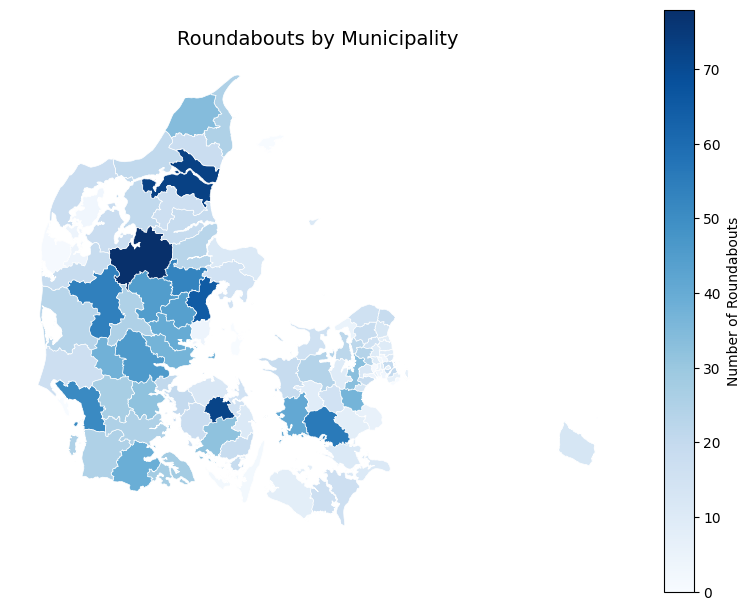

In [138]:
gdf = gpd.read_file(
    "municipalities.geojson"
)
gdf["lau_1"] = gdf["lau_1"].astype(int)

gdf = gdf.merge(
    roundabout_df,
    left_on="lau_1",
    right_on="kommune_nr",
    how="left"
)

# plot
fig, ax = plt.subplots(
    figsize=(8, 10)
)

gdf.plot(
    column="roundabout_count",
    cmap="Blues",
    legend=True,
    legend_kwds={
        "label": "Number of Roundabouts",
        "shrink": 0.6
    },
    ax=ax,
    edgecolor="white",
    linewidth=0.5
)

ax.set_title(
    "Roundabouts by Municipality",
    fontsize=14
)

ax.set_axis_off()

plt.tight_layout()

plt.show()